# Libraries

In [ ]:
!pip -q install -U "transformers==4.46.3" "accelerate==1.0.1" "datasets==2.21.0" "evaluate==0.4.3" "tokenizers==0.20.3" "scikit-learn"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.9/330.9 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 121.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 156.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 19.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [ ]:
import transformers, accelerate, datasets, evaluate, tokenizers
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)
print("datasets:", datasets.__version__)
print("evaluate:", evaluate.__version__)
print("tokenizers:", tokenizers.__version__)

transformers: 4.46.3
accelerate: 1.0.1
datasets: 2.21.0
evaluate: 0.4.3
tokenizers: 0.20.3


In [ ]:
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import AutoTokenizer, DataCollatorWithPadding
from sklearn.metrics import f1_score, classification_report

## DataSet

In [ ]:
SOURCE = "hf://datasets/DaniilOr/SemEval-2026-Task13/"

# foe task A
splits = {
    'a_train': 'task_a/task_a_training_set_1.parquet',
    'a_validation': 'task_a/task_a_validation_set.parquet',
    'a_test': 'task_a/task_a_test_set_sample.parquet'}
df_a_train = pd.read_parquet(SOURCE + splits["a_train"])
df_a_validation = pd.read_parquet(SOURCE + splits["a_validation"])
df_a_test = pd.read_parquet(SOURCE + splits["a_test"])



print("Task A:", df_a_train.shape, df_a_validation.shape, df_a_test.shape)

Task A: (500000, 4) (100000, 4) (1000, 4)


###Dataset Audit

In [ ]:
def audit_split(df: pd.DataFrame, name: str):
    print("="*80)
    print(f"{name} shape: {df.shape}")
    print("- Columns:")
    print(list(df.columns))
    print()

    #heuristics to find likely column names
    col_lower = {c.lower(): c for c in df.columns}
    candidate_lang = [c for c in df.columns if c.lower() in ["language", "lang", "programming_language", "pl"]]
    candidate_label = [c for c in df.columns if c.lower() in ["label", "target", "y", "class"]]
    candidate_code = [c for c in df.columns if c.lower() in ["code", "snippet", "content", "text"]]

    print("- Candidate columns (heuristic):")
    print("  language:", candidate_lang)
    print("  label:", candidate_label)
    print("  code:", candidate_code)
    print()

    #colomns names
    def guess_col(keywords):
        for c in df.columns:
            cl = c.lower()
            if any(k in cl for k in keywords):
                return c
        return None

    lang_col = candidate_lang[0] if candidate_lang else guess_col(["lang"])
    label_col = candidate_label[0] if candidate_label else guess_col(["label", "target", "class"])
    code_col = candidate_code[0] if candidate_code else guess_col(["code", "snippet", "content", "text"])


    for c, cname in [("lang_col", lang_col), ("label_col", label_col), ("code_col", code_col)]:
        if cname is not None:
            na = df[cname].isna().mean() * 100
            print(f"- Missing rate in {cname}: {na:.2f}%")
    print()

    #value counts
    if label_col is not None:
        print("- Label distribution:")
        print(df[label_col].value_counts(dropna=False).head(20))
        print()

    if lang_col is not None:
        print("- Language distribution:")
        print(df[lang_col].value_counts(dropna=False).head(50))
        print()

    if (lang_col is not None) and (label_col is not None):
        print("- Language × Label (counts):")
        ct = pd.crosstab(df[lang_col], df[label_col], dropna=False)
        print(ct)
        print()
        print("- Language × Label (row-normalized %):")
        ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
        print(ct_pct.round(2))
        print()
    #code length
    if code_col is not None:
        lens = df[code_col].astype(str).str.len()
        print("- Code length (characters) summary:")
        print(lens.describe(percentiles=[.05, .25, .5, .75, .95]).round(2))
        print()

#split sizes
print("Split sizes:")
print("Train:", df_a_train.shape)
print("Valid:", df_a_validation.shape)
print("Test :", df_a_test.shape)

#audit each split
audit_split(df_a_train, "TASK A - TRAIN")
audit_split(df_a_validation, "TASK A - VALIDATION")
audit_split(df_a_test, "TASK A - TEST")


Split sizes:
Train: (500000, 4)
Valid: (100000, 4)
Test : (1000, 4)
TASK A - TRAIN shape: (500000, 4)
- Columns:
['code', 'generator', 'label', 'language']

- Candidate columns (heuristic):
  language: ['language']
  label: ['label']
  code: ['code']

- Missing rate in language: 0.00%
- Missing rate in label: 0.00%
- Missing rate in code: 0.00%

- Label distribution:
label
1    261525
0    238475
Name: count, dtype: int64

- Language distribution:
language
Python    457306
C++        23392
Java       19302
Name: count, dtype: int64

- Language × Label (counts):
label          0       1
language                
C++        11147   12245
Java        9225   10077
Python    218103  239203

- Language × Label (row-normalized %):
label         0      1
language              
C++       47.65  52.35
Java      47.79  52.21
Python    47.69  52.31

- Code length (characters) summary:
count    500000.00
mean        836.87
std        1372.76
min           0.00
5%          128.00
25%         255.00
5

Because the training set we have has a big imbalance between the languages, we will downsize the data for python keeping the ratio between human written and generated code for python like in the original training set

In [ ]:
SEED = 42 #for reproducibility
PY_TARGET_N = 50_000

#spliting training by language
train_cpp  = df_a_train[df_a_train["language"] == "C++"].copy()
train_java = df_a_train[df_a_train["language"] == "Java"].copy()
train_py   = df_a_train[df_a_train["language"] == "Python"].copy()

print("Original train sizes:")
print("  C++  :", len(train_cpp))
print("  Java :", len(train_java))
print("  Python:", len(train_py))

#python label proportions
py_label_counts = train_py["label"].value_counts().sort_index()
py_total = py_label_counts.sum()
py_p0 = py_label_counts.get(0, 0) / py_total
py_p1 = py_label_counts.get(1, 0) / py_total

n0 = int(round(PY_TARGET_N * py_p0))
n1 = PY_TARGET_N - n0

print("\nPython label proportions in original train:")
print(py_label_counts)
print(f"  p(label=0)={py_p0:.4f}, p(label=1)={py_p1:.4f}")
print(f"Sampling Python to {PY_TARGET_N} with n0={n0}, n1={n1}")

#stratified sampling for Python
py0 = train_py[train_py["label"] == 0]
py1 = train_py[train_py["label"] == 1]

assert len(py0) >= n0 and len(py1) >= n1, "Not enough python samples in one of the labels."

py0_s = py0.sample(n=n0, random_state=SEED)
py1_s = py1.sample(n=n1, random_state=SEED)

train_py_sub = pd.concat([py0_s, py1_s], axis=0)

train_sub = pd.concat([train_cpp, train_java, train_py_sub], axis=0)

train_sub = train_sub.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print("\nFinal training subset size:", train_sub.shape)

print("\nLanguage distribution in train_sub:")
print(train_sub["language"].value_counts())

print("\nOverall label distribution in train_sub:")
print(train_sub["label"].value_counts(normalize=False))
print(train_sub["label"].value_counts(normalize=True).round(4))

print("\nPython label distribution in train_sub:")
print(train_sub[train_sub["language"]=="Python"]["label"].value_counts(normalize=False))
print(train_sub[train_sub["language"]=="Python"]["label"].value_counts(normalize=True).round(4))


Original train sizes:
  C++  : 23392
  Java : 19302
  Python: 457306

Python label proportions in original train:
label
0    218103
1    239203
Name: count, dtype: int64
  p(label=0)=0.4769, p(label=1)=0.5231
Sampling Python to 50000 with n0=23847, n1=26153

Final training subset size: (92694, 4)

Language distribution in train_sub:
language
Python    50000
C++       23392
Java      19302
Name: count, dtype: int64

Overall label distribution in train_sub:
label
1    48475
0    44219
Name: count, dtype: int64
label
1    0.523
0    0.477
Name: proportion, dtype: float64

Python label distribution in train_sub:
label
1    26153
0    23847
Name: count, dtype: int64
label
1    0.5231
0    0.4769
Name: proportion, dtype: float64


We filter the samples with extremely short or excessively long, to respect model input constraints and ensure stable training

In [ ]:
SEED = 42

MIN_LEN = 50
MAX_LEN = 12000

SEEN_LANGS = {"Python", "Java", "C++"}
UNSEEN_LANGS = {"Go", "PHP", "C#", "C", "JavaScript"}

def add_len(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["code_len"] = df["code"].astype(str).str.len()
    return df

def filter_len(df: pd.DataFrame, name: str) -> pd.DataFrame:
    df = add_len(df)
    before = len(df)
    df_f = df[(df["code_len"] >= MIN_LEN) & (df["code_len"] <= MAX_LEN)].copy()
    after = len(df_f)
    print(f"{name}: {before} → {after} kept ({after/before:.2%}); removed {before-after}")
    return df_f

def summarize_len(df: pd.DataFrame, name: str):
    s = df["code_len"].describe(percentiles=[.05,.25,.5,.75,.95]).round(2)
    print(f"\n{name} code_len summary:")
    print(s)

train_f = filter_len(train_sub, "TRAIN_SUB (filtered)")
val_f   = filter_len(df_a_validation, "VALID (filtered)")
test_f  = filter_len(df_a_test, "TEST (filtered)")

summarize_len(train_f, "TRAIN_SUB (filtered)")
summarize_len(val_f, "VALID (filtered)")
summarize_len(test_f, "TEST (filtered)")

#evaluation slices
val_seen = val_f[val_f["language"].isin(SEEN_LANGS)].copy()

test_seen = test_f[test_f["language"].isin(SEEN_LANGS)].copy()
test_unseen = test_f[test_f["language"].isin(UNSEEN_LANGS)].copy()

print("\nEvaluation slices after filtering:")
print("val_seen:", val_seen.shape, "| languages:", val_seen["language"].unique())
print("test_seen:", test_seen.shape, "| languages:", test_seen["language"].unique())
print("test_unseen:", test_unseen.shape, "| languages:", test_unseen["language"].unique())

print("\nUnseen language counts in test_unseen:")
print(test_unseen["language"].value_counts())

print("\nLabel balance checks:")
print("train_f label %:\n", train_f["label"].value_counts(normalize=True).round(4))
print("val_seen label %:\n", val_seen["label"].value_counts(normalize=True).round(4))
print("test_unseen label %:\n", test_unseen["label"].value_counts(normalize=True).round(4))


TRAIN_SUB (filtered): 92694 → 91996 kept (99.25%); removed 698
VALID (filtered): 100000 → 99583 kept (99.58%); removed 417
TEST (filtered): 1000 → 998 kept (99.80%); removed 2

TRAIN_SUB (filtered) code_len summary:
count    91996.00
mean      1133.27
std       1266.82
min         50.00
5%         152.00
25%        343.00
50%        701.00
75%       1472.00
95%       3288.00
max      11992.00
Name: code_len, dtype: float64

VALID (filtered) code_len summary:
count    99583.00
mean       813.90
std        912.33
min         50.00
5%         131.00
25%        255.00
50%        463.00
75%       1010.00
95%       2732.00
max      11950.00
Name: code_len, dtype: float64

TEST (filtered) code_len summary:
count      998.00
mean      1360.42
std       1526.80
min         59.00
5%         206.95
25%        431.50
50%        848.00
75%       1626.00
95%       4459.05
max      11937.00
Name: code_len, dtype: float64

Evaluation slices after filtering:
val_seen: (99583, 5) | languages: ['Python' 

###Test.parquet file

In [ ]:
import pandas as pd

df_test_full = pd.read_parquet("/content/test.parquet")
print("Full test shape:", df_test_full.shape)
df_test_full.head()


Full test shape: (500000, 2)


,ID,code
0,0,"(H, W) = map(int, input().split())\nA = [list(..."
2,2,"n = int(input())\nt = list(map(int, input().sp..."
5,5,import sys\n\nclass LazySegmentTree:\n def ...
6,6,n = int(input())\ns = input()\ntup = []\nfor i...
7,7,import sys\ninput = sys.stdin.readline\nfrom m...


In [ ]:
import numpy as np
import pandas as pd

df_blind = df_test_full.copy()
df_blind["len"] = df_blind["code"].astype(str).str.len()

#10 quantile bins
df_blind["len_bin"] = pd.qcut(df_blind["len"], q=10, duplicates="drop")

print(df_blind["len"].describe())
print("\nBin counts:")
print(df_blind["len_bin"].value_counts().sort_index())


count    500000.000000
mean       1420.613680
std        1643.825449
min           2.000000
25%         440.000000
50%         843.000000
75%        1728.000000
max       54080.000000
Name: len, dtype: float64

Bin counts:
len_bin
(1.999, 274.0]       50272
(274.0, 382.0]       49758
(382.0, 503.0]       50301
(503.0, 651.0]       49949
(651.0, 843.0]       49825
(843.0, 1103.0]      49900
(1103.0, 1472.0]     49996
(1472.0, 2065.0]     50028
(2065.0, 3231.0]     50000
(3231.0, 54080.0]    49971
Name: count, dtype: int64


In [ ]:
#stratified sample of 100k from the blind test set
TARGET_SIZE = 100_000
SEED = 42

bin_counts = df_blind["len_bin"].value_counts()
bin_props = bin_counts / len(df_blind)
bin_targets = (bin_props * TARGET_SIZE).round().astype(int)

dfs = []
for b, n in bin_targets.items():
    part = df_blind[df_blind["len_bin"] == b]
    dfs.append(part.sample(n=int(n), random_state=SEED))

df_blind_100k = pd.concat(dfs).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Final sample size:", len(df_blind_100k))
print("\nCheck bin proportions (full vs sample):")
check = pd.DataFrame({
    "full": df_blind["len_bin"].value_counts(normalize=True).sort_index(),
    "sample": df_blind_100k["len_bin"].value_counts(normalize=True).sort_index()
}).round(4)
check


Final sample size: 100000

Check bin proportions (full vs sample):


,full,sample
len_bin,,
"(1.999, 274.0]",0.1005,0.1005
"(274.0, 382.0]",0.0995,0.0995
"(382.0, 503.0]",0.1006,0.1006
"(503.0, 651.0]",0.0999,0.0999
"(651.0, 843.0]",0.0996,0.0996
"(843.0, 1103.0]",0.0998,0.0998
"(1103.0, 1472.0]",0.1000,0.1000
"(1472.0, 2065.0]",0.1001,0.1001
"(2065.0, 3231.0]",0.1000,0.1000


In [ ]:
from datasets import Dataset

df_blind_100k_hf = df_blind_100k.copy()
df_blind_100k_hf["len_bin"] = df_blind_100k_hf["len_bin"].astype(str)

ds_blind_100k = Dataset.from_pandas(df_blind_100k_hf[["ID", "code", "len", "len_bin"]], preserve_index=False)
ds_blind_100k

Dataset({
    features: ['ID', 'code', 'len', 'len_bin'],
    num_rows: 100000
})

###Tokenization

In [ ]:
train_df = train_f[["code", "label", "language"]].copy()
val_df   = val_seen[["code", "label", "language"]].copy()
test_unseen_df = test_unseen[["code", "label", "language"]].copy()
test_seen_df   = test_seen[["code", "label", "language"]].copy()

ds_train = Dataset.from_pandas(train_df.reset_index(drop=True))
ds_val   = Dataset.from_pandas(val_df.reset_index(drop=True))
ds_test_unseen = Dataset.from_pandas(test_unseen_df.reset_index(drop=True))
ds_test_seen   = Dataset.from_pandas(test_seen_df.reset_index(drop=True))

print(ds_train, ds_val, ds_test_unseen, ds_test_seen)


Dataset({
    features: ['code', 'label', 'language'],
    num_rows: 91996
}) Dataset({
    features: ['code', 'label', 'language'],
    num_rows: 99583
}) Dataset({
    features: ['code', 'label', 'language'],
    num_rows: 365
}) Dataset({
    features: ['code', 'label', 'language'],
    num_rows: 633
})


In [ ]:
MODEL_NAME = "microsoft/codebert-base"
MAX_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def tokenize_batch(batch):
    return tokenizer(
        batch["code"],
        truncation=True,
        max_length=MAX_LEN
    )

ds_train_tok = ds_train.map(tokenize_batch, batched=True, remove_columns=["code"])
ds_val_tok   = ds_val.map(tokenize_batch, batched=True, remove_columns=["code"])
ds_test_unseen_tok = ds_test_unseen.map(tokenize_batch, batched=True, remove_columns=["code"])
ds_test_seen_tok   = ds_test_seen.map(tokenize_batch, batched=True, remove_columns=["code"])

#format for PyTorch
cols = ["input_ids", "attention_mask", "label"]
ds_train_tok.set_format(type="torch", columns=cols)
ds_val_tok.set_format(type="torch", columns=cols)
ds_test_unseen_tok.set_format(type="torch", columns=cols)
ds_test_seen_tok.set_format(type="torch", columns=cols)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Datasets ready.")


Map:   0%|          | 0/91996 [00:00<?, ? examples/s]

Map:   0%|          | 0/99583 [00:00<?, ? examples/s]

Map:   0%|          | 0/365 [00:00<?, ? examples/s]

Map:   0%|          | 0/633 [00:00<?, ? examples/s]

Datasets ready.


In [ ]:
#sanity check
for d in [ds_train_tok, ds_val_tok, ds_test_unseen_tok, ds_test_seen_tok]:
    d.reset_format()

ex = ds_train_tok[0]
print("Tokenized keys:", ex.keys())
print("Example input_ids length:", len(ex["input_ids"]))
print("Example label:", ex["label"])

train_labels = np.array(list(ds_train["label"]), dtype=np.int64)
val_labels   = np.array(list(ds_val["label"]), dtype=np.int64)
testu_labels = np.array(list(ds_test_unseen["label"]), dtype=np.int64)

print("\nUnique labels:")
print("Train:", np.unique(train_labels))
print("Val  :", np.unique(val_labels))
print("TestU:", np.unique(testu_labels))

print("\nLabel counts [0,1]:")
print("Train:", np.bincount(train_labels))
print("Val  :", np.bincount(val_labels))
print("TestU:", np.bincount(testu_labels))


Tokenized keys: dict_keys(['label', 'language', 'input_ids', 'attention_mask'])
Example input_ids length: 256
Example label: 1

Unique labels:
Train: [0 1]
Val  : [0 1]
TestU: [0 1]

Label counts [0,1]:
Train: [43661 48335]
Val  : [47447 52136]
TestU: [276  89]


In [ ]:
ds_train_tok.save_to_disk("/content/ds_train_tok")
ds_val_tok.save_to_disk("/content/ds_val_tok")
ds_test_unseen_tok.save_to_disk("/content/ds_test_unseen_tok")
ds_test_seen_tok.save_to_disk("/content/ds_test_seen_tok")

print("Saved tokenized datasets to disk.")


Saving the dataset (0/1 shards):   0%|          | 0/91996 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/99583 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/365 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/633 [00:00<?, ? examples/s]

Saved tokenized datasets to disk.


# Experiments

##Baseline Logistic Regresion

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

X_train = train_f["code"].astype(str).tolist()
y_train = train_f["label"].astype(int).to_numpy()

X_val = val_seen["code"].astype(str).tolist()
y_val = val_seen["label"].astype(int).to_numpy()


tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=3,
    max_features=200_000
)

Xtr = tfidf.fit_transform(X_train)
Xva = tfidf.transform(X_val)

clf = LogisticRegression(
    max_iter=200,
    n_jobs=-1,
    class_weight=None
)
clf.fit(Xtr, y_train)

val_pred = clf.predict(Xva)

macro_f1 = f1_score(y_val, val_pred, average="macro")
print("Baseline (TF-IDF + LogisticRegression) Macro-F1 on val_seen:", round(macro_f1, 4))
print("\nClassification report:")
print(classification_report(y_val, val_pred, digits=4))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Baseline (TF-IDF + LogisticRegression) Macro-F1 on val_seen: 0.9334

Classification report:
              precision    recall  f1-score   support

           0     0.9202    0.9421    0.9311     47447
           1     0.9462    0.9257    0.9358     52136

    accuracy                         0.9335     99583
   macro avg     0.9332    0.9339    0.9334     99583
weighted avg     0.9338    0.9335    0.9335     99583



###Blind test

In [ ]:
X_blind = df_blind_100k["code"].astype(str).tolist()
X_blind_vec = tfidf.transform(X_blind)
df_pred["pred_baseline"] = clf.predict(X_blind_vec)
df_pred.head()

,ID,len,len_bin,pred_codebert,pred_gcb,pred_baseline
0,273187,849,"(843.0, 1103.0]",1,1,1
1,467587,772,"(651.0, 843.0]",0,1,1
2,173456,119,"(1.999, 274.0]",1,1,1
3,611201,870,"(843.0, 1103.0]",1,1,0
4,34534,373,"(274.0, 382.0]",0,0,0


##CodeBert

Finetuning CodeBert to see what is the optimal learning rate and epoch to train

In [ ]:
import gc
import numpy as np
import pandas as pd
import torch
import evaluate

from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

metric_f1 = evaluate.load("f1")


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "macro_f1": metric_f1.compute(
            predictions=preds,
            references=labels,
            average="macro"
        )["f1"]
    }

In [ ]:
def lr_to_name(lr: float) -> str:
    return f"{int(round(lr * 1e5))}e5"

def train_one_lr(lr: float):
    run_name = lr_to_name(lr)
    print(f"\n Training CodeBERT with learning rate = {lr} (run={run_name})")

    model = AutoModelForSequenceClassification.from_pretrained(
        "microsoft/codebert-base",
        num_labels=2
    )

    args = TrainingArguments(
        output_dir=f"./codebert_lr_{run_name}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=5,
        weight_decay=0.01,
        fp16=True,
        logging_steps=200,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=ds_train_tok,
        eval_dataset=ds_val_tok,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    train_out = trainer.train()
    eval_out = trainer.evaluate()

    best_f1 = trainer.state.best_metric
    best_ckpt = trainer.state.best_model_checkpoint

    del trainer
    del model
    gc.collect()
    torch.cuda.empty_cache()

    return {
        "learning_rate": lr,
        "best_macro_f1": float(best_f1) if best_f1 is not None else None,
        "eval_macro_f1": float(eval_out.get("eval_macro_f1", np.nan)),
        "best_checkpoint": best_ckpt,
        "train_runtime_sec": float(train_out.metrics.get("train_runtime", np.nan))
    }


In [ ]:
learning_rates = [1e-5, 2e-5, 3e-5]
results = []

for lr in learning_rates:
    res = train_one_lr(lr)
    results.append(res)
    print("Finished:", res)

results_df = (
    pd.DataFrame(results)
    .sort_values("best_macro_f1", ascending=False)
    .reset_index(drop=True)
)

print("\n Learning-rate sweep results:")
results_df


 Training CodeBERT with learning rate = 1e-05 (run=1e5)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipython-input-1374351450.py:31: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Macro F1
1,0.106700,0.048045,0.987854
2,0.085600,0.043882,0.990590
3,0.056100,0.051956,0.989548
4,0.053600,0.045042,0.990874
5,0.045500,0.049664,0.990814


Finished: {'learning_rate': 1e-05, 'best_macro_f1': 0.9908739106007358, 'eval_macro_f1': 0.9908739106007358, 'best_checkpoint': './codebert_lr_1e5/checkpoint-23000', 'train_runtime_sec': 1887.9}

 Training CodeBERT with learning rate = 2e-05 (run=2e5)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipython-input-1374351450.py:31: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipython-input-1374351450.py:31: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Macro F1
1,0.107100,0.041627,0.989211
2,0.084100,0.037628,0.990811
3,0.057800,0.044879,0.990815
4,0.037800,0.041753,0.991759
5,0.036100,0.047400,0.991488


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Finished: {'learning_rate': 3e-05, 'best_macro_f1': 0.9917590855470895, 'eval_macro_f1': 0.9917590855470895, 'best_checkpoint': './codebert_lr_3e5/checkpoint-23000', 'train_runtime_sec': 1886.3721}

 Learning-rate sweep results:


,learning_rate,best_macro_f1,eval_macro_f1,best_checkpoint,train_runtime_sec
0,0.00003,0.991759,0.991759,./codebert_lr_3e5/checkpoint-23000,1886.3721
1,0.00002,0.991296,0.991296,./codebert_lr_2e5/checkpoint-23000,1890.6397
2,0.00001,0.990874,0.990874,./codebert_lr_1e5/checkpoint-23000,1887.9000


In [ ]:
best = results_df.iloc[0]
BEST_LR = float(best["learning_rate"])
BEST_CKPT = best["best_checkpoint"]

print("Selected LR:", BEST_LR)
print("Selected checkpoint:", BEST_CKPT)
results_df

Selected LR: 3e-05
Selected checkpoint: ./codebert_lr_3e5/checkpoint-23000


,learning_rate,best_macro_f1,eval_macro_f1,best_checkpoint,train_runtime_sec
0,0.00003,0.991759,0.991759,./codebert_lr_3e5/checkpoint-23000,1886.3721
1,0.00002,0.991296,0.991296,./codebert_lr_2e5/checkpoint-23000,1890.6397
2,0.00001,0.990874,0.990874,./codebert_lr_1e5/checkpoint-23000,1887.9000


In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer

model_exp1 = AutoModelForSequenceClassification.from_pretrained(BEST_CKPT)
model_exp1.eval()

trainer_eval = Trainer(
    model=model_exp1,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

/tmp/ipython-input-3863898268.py:6: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_eval = Trainer(


In [ ]:
eval_val = trainer_eval.evaluate(ds_val_tok)
print("Experiment 1 — CodeBERT on val_seen:", eval_val)

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Experiment 1 — CodeBERT on val_seen: {'eval_loss': 0.041754428297281265, 'eval_model_preparation_time': 0.0031, 'eval_macro_f1': 0.9917590855470895, 'eval_runtime': 188.3284, 'eval_samples_per_second': 528.773, 'eval_steps_per_second': 66.097}


In [ ]:
eval_test_seen = trainer_eval.evaluate(ds_test_seen_tok)
print("Sanity — CodeBERT on test_seen:", eval_test_seen)

Sanity — CodeBERT on test_seen: {'eval_loss': 6.406222820281982, 'eval_model_preparation_time': 0.0031, 'eval_macro_f1': 0.31977865263327043, 'eval_runtime': 1.3751, 'eval_samples_per_second': 460.319, 'eval_steps_per_second': 58.176}


In [ ]:
BASELINE_MACRO_F1 = 0.9334

exp1_table = pd.DataFrame([
    {"Model": "TF-IDF (char 3–5) + Logistic Regression", "Split": "val_seen", "Macro-F1": BASELINE_MACRO_F1},
    {"Model": f"CodeBERT fine-tuned (lr={BEST_LR})", "Split": "val_seen", "Macro-F1": eval_val["eval_macro_f1"]},
    {"Model": f"CodeBERT fine-tuned (lr={BEST_LR})", "Split": "test_seen (sanity)", "Macro-F1": eval_test_seen["eval_macro_f1"]},
])
exp1_table


,Model,Split,Macro-F1
0,TF-IDF (char 3–5) + Logistic Regression,val_seen,0.933400
1,CodeBERT fine-tuned (lr=3e-05),val_seen,0.991759
2,CodeBERT fine-tuned (lr=3e-05),test_seen (sanity),0.319779


### Diagnosis

In [ ]:
print("test_seen shape:", test_seen.shape)
print("test_seen label counts:\n", test_seen["label"].value_counts())
print("test_seen language counts:\n", test_seen["language"].value_counts())


test_seen shape: (633, 5)
test_seen label counts:
 label
0    499
1    134
Name: count, dtype: int64
test_seen language counts:
 language
Python    302
Java      256
C++        75
Name: count, dtype: int64


In [ ]:
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix, classification_report

pred_out = trainer_eval.predict(ds_test_seen_tok)
preds = np.argmax(pred_out.predictions, axis=1)
y_true = np.array(ds_test_seen["label"])

print("Manual macro-F1 (test_seen):", f1_score(y_true, preds, average="macro"))
print("\nConfusion matrix:\n", confusion_matrix(y_true, preds))
print("\nReport:\n", classification_report(y_true, preds, digits=4))


Manual macro-F1 (test_seen): 0.31977865263327043

Confusion matrix:
 [[ 78 421]
 [  7 127]]

Report:
               precision    recall  f1-score   support

           0     0.9176    0.1563    0.2671       499
           1     0.2318    0.9478    0.3724       134

    accuracy                         0.3239       633
   macro avg     0.5747    0.5520    0.3198       633
weighted avg     0.7724    0.3239    0.2894       633



In [ ]:
print("BEST_LR:", BEST_LR)
print("BEST_CKPT:", BEST_CKPT)


pred_out_val = trainer_eval.predict(ds_val_tok)
preds_val = np.argmax(pred_out_val.predictions, axis=1)
y_val_true = np.array(ds_val["label"])
print("Manual macro-F1 (val_seen):", f1_score(y_val_true, preds_val, average="macro"))


BEST_LR: 3e-05
BEST_CKPT: ./codebert_lr_3e5/checkpoint-23000


Manual macro-F1 (val_seen): 0.9917590855470895


In [ ]:
from datasets import Dataset

test_seen_df = test_seen[["code", "label", "language"]].reset_index(drop=True)
ds_test_seen_fresh = Dataset.from_pandas(test_seen_df)

def tokenize_batch(batch):
    return tokenizer(batch["code"], truncation=True, max_length=256)

ds_test_seen_tok_fresh = ds_test_seen_fresh.map(tokenize_batch, batched=True, remove_columns=["code", "language"])
ds_test_seen_tok_fresh.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

pred_out = trainer_eval.predict(ds_test_seen_tok_fresh)
preds = np.argmax(pred_out.predictions, axis=1)
y_true = np.array(ds_test_seen_fresh["label"])

print("Manual macro-F1 (test_seen, fresh):", f1_score(y_true, preds, average="macro"))
print("\nConfusion matrix:\n", confusion_matrix(y_true, preds))


Map:   0%|          | 0/633 [00:00<?, ? examples/s]

Manual macro-F1 (test_seen, fresh): 0.31977865263327043

Confusion matrix:
 [[ 78 421]
 [  7 127]]


###Blind test

In [ ]:
def tok_codebert(batch):
    return tokenizer(batch["code"], truncation=True, max_length=256)

ds_blind_cb = ds_blind_100k.map(tok_codebert, batched=True, remove_columns=["code", "len", "len_bin"])
ds_blind_cb.set_format(type="torch", columns=["input_ids", "attention_mask"])

pred_cb = trainer_eval.predict(ds_blind_cb)
pred_cb_label = np.argmax(pred_cb.predictions, axis=1)

df_pred = df_blind_100k[["ID", "len", "len_bin"]].copy()
df_pred["pred_codebert"] = pred_cb_label
df_pred.head()


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

,ID,len,len_bin,pred_codebert
0,273187,849,"(843.0, 1103.0]",1
1,467587,772,"(651.0, 843.0]",0
2,173456,119,"(1.999, 274.0]",1
3,611201,870,"(843.0, 1103.0]",1
4,34534,373,"(274.0, 382.0]",0


Diagrams

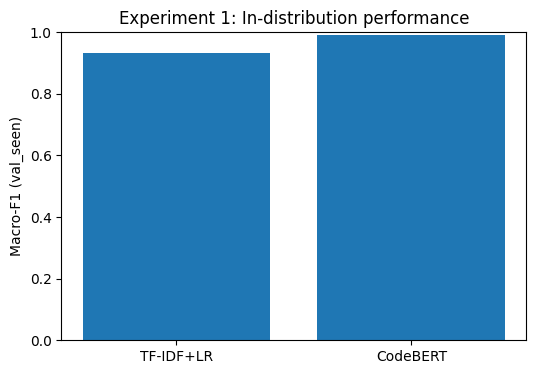

In [ ]:
import matplotlib.pyplot as plt

baseline_val = 0.9334
codebert_val = eval_val["eval_macro_f1"]

plt.figure(figsize=(6,4))
plt.bar(["TF-IDF+LR", "CodeBERT"], [baseline_val, codebert_val])
plt.ylabel("Macro-F1 (val_seen)")
plt.title("Experiment 1: In-distribution performance")
plt.ylim(0, 1.0)
plt.show()


<Figure size 500x400 with 0 Axes>

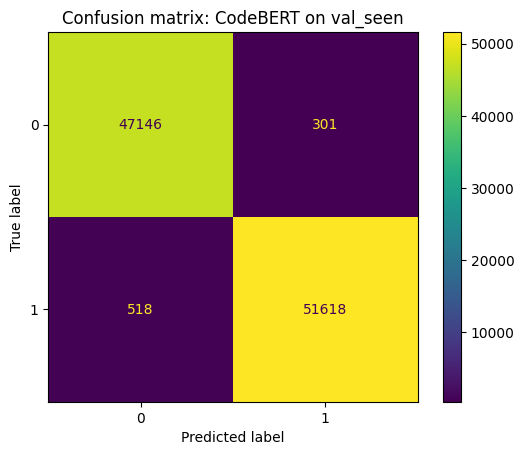

In [ ]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

pred_out_val = trainer_eval.predict(ds_val_tok)
preds_val = np.argmax(pred_out_val.predictions, axis=1)
y_val_true = np.array(ds_val["label"])

cm = confusion_matrix(y_val_true, preds_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])

plt.figure(figsize=(5,4))
disp.plot(values_format="d")
plt.title("Confusion matrix: CodeBERT on val_seen")
plt.show()


<Figure size 500x400 with 0 Axes>

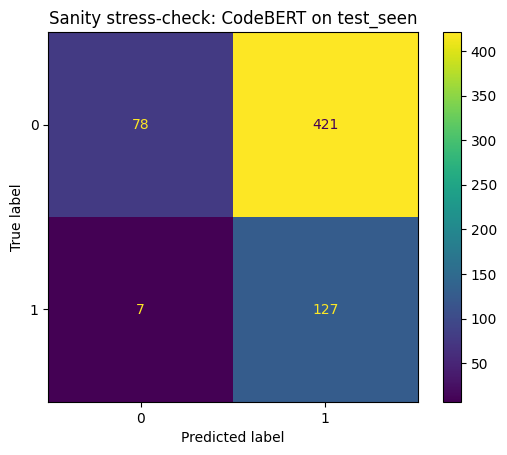

In [ ]:
pred_out_ts = trainer_eval.predict(ds_test_seen_tok)
preds_ts = np.argmax(pred_out_ts.predictions, axis=1)
y_ts_true = np.array(ds_test_seen["label"])

cm_ts = confusion_matrix(y_ts_true, preds_ts)
disp_ts = ConfusionMatrixDisplay(confusion_matrix=cm_ts, display_labels=[0,1])

plt.figure(figsize=(5,4))
disp_ts.plot(values_format="d")
plt.title("Sanity stress-check: CodeBERT on test_seen")
plt.show()


## Unseen Languages

In [ ]:
eval_unseen = trainer_eval.evaluate(ds_test_unseen_tok)
print("Experiment 2 — CodeBERT overall Macro-F1 unseen languages:", eval_unseen)

Experiment 2 — CodeBERT overall Macro-F1 unseen languages: {'eval_loss': 6.919017314910889, 'eval_model_preparation_time': 0.0031, 'eval_macro_f1': 0.20977892278205, 'eval_runtime': 0.7535, 'eval_samples_per_second': 484.424, 'eval_steps_per_second': 61.051}


###CodeBert

In [ ]:
from sklearn.metrics import f1_score

def per_language_f1_codebert(ds_tok, df_raw):
    preds_out = trainer_eval.predict(ds_tok)
    preds = np.argmax(preds_out.predictions, axis=1)
    y_true = df_raw["label"].astype(int).to_numpy()
    langs = df_raw["language"].values

    rows = []
    for lang in sorted(np.unique(langs)):
        idx = np.where(langs == lang)[0]
        rows.append({
            "language": lang,
            "n": len(idx),
            "macro_f1_codebert": f1_score(y_true[idx], preds[idx], average="macro")
        })
    return pd.DataFrame(rows)

cb_by_lang = per_language_f1_codebert(ds_test_unseen_tok, test_unseen)
cb_by_lang


,language,n,macro_f1_codebert
0,C,51,0.291667
1,C#,121,0.205765
2,Go,60,0.189189
3,JavaScript,85,0.230826
4,PHP,48,0.081739


###Baseline on unseen languages

In [ ]:
from sklearn.metrics import f1_score, classification_report

X_unseen = test_unseen["code"].astype(str).tolist()
y_unseen = test_unseen["label"].astype(int).to_numpy()

X_unseen_vec = tfidf.transform(X_unseen)
pred_base = clf.predict(X_unseen_vec)

print("Baseline overall Macro-F1 unseen languages:",
      f1_score(y_unseen, pred_base, average="macro"))
print(classification_report(y_unseen, pred_base, digits=4))


Baseline overall Macro-F1 unseen languages: 0.21043074591044023
              precision    recall  f1-score   support

           0     0.6250    0.0181    0.0352       276
           1     0.2409    0.9663    0.3857        89

    accuracy                         0.2493       365
   macro avg     0.4329    0.4922    0.2104       365
weighted avg     0.5313    0.2493    0.1207       365



In [ ]:
def per_language_f1_baseline(df_raw, y_pred):
    y_true = df_raw["label"].astype(int).to_numpy()
    langs = df_raw["language"].values

    rows = []
    for lang in sorted(np.unique(langs)):
        idx = np.where(langs == lang)[0]
        rows.append({
            "language": lang,
            "n": len(idx),
            "macro_f1_baseline": f1_score(y_true[idx], y_pred[idx], average="macro")
        })
    return pd.DataFrame(rows)

base_by_lang = per_language_f1_baseline(test_unseen, pred_base)
base_by_lang

,language,n,macro_f1_baseline
0,C,51,0.230561
1,C#,121,0.194200
2,Go,60,0.210526
3,JavaScript,85,0.273504
4,PHP,48,0.058824


Merging results

In [ ]:
exp2_table = cb_by_lang.merge(
    base_by_lang, on=["language", "n"]
)
exp2_table["delta"] = exp2_table["macro_f1_codebert"] - exp2_table["macro_f1_baseline"]
exp2_table.sort_values("delta", ascending=False)


,language,n,macro_f1_codebert,macro_f1_baseline,delta
0,C,51,0.291667,0.230561,0.061106
4,PHP,48,0.081739,0.058824,0.022916
1,C#,121,0.205765,0.194200,0.011565
2,Go,60,0.189189,0.210526,-0.021337
3,JavaScript,85,0.230826,0.273504,-0.042678


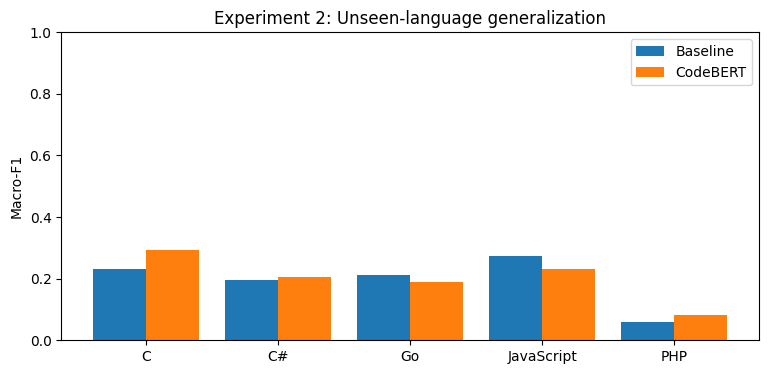

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

dfp = exp2_table.sort_values("language")
x = np.arange(len(dfp))

plt.figure(figsize=(9,4))
plt.bar(x - 0.2, dfp["macro_f1_baseline"], 0.4, label="Baseline")
plt.bar(x + 0.2, dfp["macro_f1_codebert"], 0.4, label="CodeBERT")
plt.xticks(x, dfp["language"])
plt.ylabel("Macro-F1")
plt.title("Experiment 2: Unseen-language generalization")
plt.legend()
plt.ylim(0,1)
plt.show()

##GraphCodeBert



Finetuning GraphCodeBert to see what is the optimal learning rate and epoch to train

In [ ]:
import os, random, gc

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

GCB_MODEL_NAME = "microsoft/graphcodebert-base"
MAX_LEN = 256
NUM_EPOCHS = 5

learning_rates_candidates = [2e-5, 3e-5, 1e-4]

print("GraphCodeBERT sweep LRs:", learning_rates_candidates)
print("Epochs (max):", NUM_EPOCHS, "| max_len:", MAX_LEN)


GraphCodeBERT sweep LRs: [2e-05, 3e-05, 0.0001]
Epochs (max): 5 | max_len: 256


In [ ]:
gcb_tokenizer = AutoTokenizer.from_pretrained(GCB_MODEL_NAME)
gcb_data_collator = DataCollatorWithPadding(tokenizer=gcb_tokenizer)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/539 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

In [ ]:
def gcb_tokenize(batch):
    return gcb_tokenizer(batch["code"], truncation=True, max_length=MAX_LEN)

#same splits as CodeBERT
ds_train_gcb = ds_train.map(gcb_tokenize, batched=True, remove_columns=["code", "language"])
ds_val_gcb = ds_val.map(gcb_tokenize, batched=True, remove_columns=["code", "language"])
ds_test_seen_gcb = ds_test_seen.map(gcb_tokenize, batched=True, remove_columns=["code", "language"])
ds_test_unseen_gcb = ds_test_unseen.map(gcb_tokenize, batched=True, remove_columns=["code", "language"])

for _ds in [ds_train_gcb, ds_val_gcb, ds_test_seen_gcb, ds_test_unseen_gcb]:
    _ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print("Tokenized sizes:",
      len(ds_train_gcb), len(ds_val_gcb), len(ds_test_seen_gcb), len(ds_test_unseen_gcb))


Map:   0%|          | 0/91996 [00:00<?, ? examples/s]

Map:   0%|          | 0/99583 [00:00<?, ? examples/s]

Map:   0%|          | 0/633 [00:00<?, ? examples/s]

Map:   0%|          | 0/365 [00:00<?, ? examples/s]

Tokenized sizes: 91996 99583 633 365


In [ ]:
def lr_to_name(lr: float) -> str:
    if abs(lr - 1e-4) < 1e-12:
        return "1e4"
    return f"{int(round(lr * 1e5))}e5"

def train_gcb_one_lr(lr: float):
    set_seed(42)
    run_name = lr_to_name(lr)
    out_dir = f"./gcb_lr_{run_name}"

    model = AutoModelForSequenceClassification.from_pretrained(
        GCB_MODEL_NAME,
        num_labels=2
    )

    args = TrainingArguments(
        output_dir=out_dir,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_steps=200,
        save_total_limit=2,
        fp16=torch.cuda.is_available(),
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=ds_train_gcb,
        eval_dataset=ds_val_gcb,
        tokenizer=gcb_tokenizer,
        data_collator=gcb_data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
    )

    print(f"\n Training GraphCodeBERT lr={lr} (run={run_name})")
    trainer.train()

    #best checkpoint
    eval_val = trainer.evaluate(ds_val_gcb)

    res = {
        "learning_rate": lr,
        "run_name": run_name,
        "best_val_macro_f1": float(eval_val["eval_macro_f1"]),
        "best_checkpoint": trainer.state.best_model_checkpoint
    }

    del trainer
    del model
    gc.collect()
    torch.cuda.empty_cache()

    print("Finished:", res)
    return res


In [ ]:
gcb_results = []
for lr in learning_rates_candidates:
    gcb_results.append(train_gcb_one_lr(lr))

gcb_results_df = (
    pd.DataFrame(gcb_results)
    .sort_values("best_val_macro_f1", ascending=False)
    .reset_index(drop=True)
)

print("\n GraphCodeBERT LR sweep:")
gcb_results_df


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/graphcodebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipython-input-2343296151.py:34: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



 Training GraphCodeBERT lr=2e-05 (run=2e5)


Epoch,Training Loss,Validation Loss,Macro F1
1,0.084800,0.036186,0.989676
2,0.067300,0.039501,0.989772
3,0.043000,0.038835,0.991116
4,0.028500,0.040915,0.992110
5,0.012000,0.049148,0.991839


Finished: {'learning_rate': 2e-05, 'run_name': '2e5', 'best_val_macro_f1': 0.9921104162506229, 'best_checkpoint': './gcb_lr_2e5/checkpoint-23000'}


...

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/graphcodebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipython-input-2343296151.py:34: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



 Training GraphCodeBERT lr=0.0001 (run=1e4)


Epoch,Training Loss,Validation Loss,Macro F1
1,0.412300,0.293974,0.936663
2,0.570200,0.700298,0.343635


Finished: {'learning_rate': 0.0001, 'run_name': '1e4', 'best_val_macro_f1': 0.9366633179921173, 'best_checkpoint': './gcb_lr_1e4/checkpoint-5750'}

 GraphCodeBERT LR sweep:


,learning_rate,run_name,best_val_macro_f1,best_checkpoint
0,0.00002,2e5,0.992110,./gcb_lr_2e5/checkpoint-23000
1,0.00003,3e5,0.991718,./gcb_lr_3e5/checkpoint-11500
2,0.00010,1e4,0.936663,./gcb_lr_1e4/checkpoint-5750


In [ ]:
from transformers import Trainer, AutoModelForSequenceClassification

best_row = gcb_results_df.iloc[0]
GCB_BEST_LR = float(best_row["learning_rate"])
GCB_BEST_CKPT = best_row["best_checkpoint"]

print("Selected GraphCodeBERT LR:", GCB_BEST_LR)
print("Selected GraphCodeBERT checkpoint:", GCB_BEST_CKPT)

gcb_best_model = AutoModelForSequenceClassification.from_pretrained(GCB_BEST_CKPT)
gcb_best_model.eval()

gcb_eval_trainer = Trainer(
    model=gcb_best_model,
    tokenizer=gcb_tokenizer,
    data_collator=gcb_data_collator,
    compute_metrics=compute_metrics
)

Selected GraphCodeBERT LR: 2e-05
Selected GraphCodeBERT checkpoint: ./gcb_lr_2e5/checkpoint-23000


/tmp/ipython-input-3440479132.py:13: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  gcb_eval_trainer = Trainer(


Validation and test

In [ ]:
gcb_eval_val = gcb_eval_trainer.evaluate(ds_val_gcb)
print("GraphCodeBERT val_seen:", gcb_eval_val)

gcb_eval_unseen = gcb_eval_trainer.evaluate(ds_test_unseen_gcb)
print("GraphCodeBERT test_unseen:", gcb_eval_unseen)

gcb_eval_seen_test = gcb_eval_trainer.evaluate(ds_test_seen_gcb)
print("GraphCodeBERT test_seen (sanity):", gcb_eval_seen_test)


GraphCodeBERT val_seen: {'eval_loss': 0.04091348499059677, 'eval_model_preparation_time': 0.0035, 'eval_macro_f1': 0.9921104162506229, 'eval_runtime': 191.5733, 'eval_samples_per_second': 519.817, 'eval_steps_per_second': 64.978}
GraphCodeBERT test_unseen: {'eval_loss': 6.4026689529418945, 'eval_model_preparation_time': 0.0035, 'eval_macro_f1': 0.2354750697552191, 'eval_runtime': 0.7441, 'eval_samples_per_second': 490.497, 'eval_steps_per_second': 61.816}
GraphCodeBERT test_seen (sanity): {'eval_loss': 6.029900074005127, 'eval_model_preparation_time': 0.0035, 'eval_macro_f1': 0.34030784030784034, 'eval_runtime': 1.2887, 'eval_samples_per_second': 491.202, 'eval_steps_per_second': 62.079}


###Unseen languages GCB

In [ ]:
from sklearn.metrics import f1_score

def per_language_macro_f1(trainer, ds_tok, df_raw, metric_col):
    preds_out = trainer.predict(ds_tok)
    preds = np.argmax(preds_out.predictions, axis=1)
    y_true = df_raw["label"].astype(int).to_numpy()
    langs = df_raw["language"].to_numpy()

    rows = []
    for lang in sorted(np.unique(langs)):
        idx = np.where(langs == lang)[0]
        rows.append({
            "language": lang,
            "n": int(len(idx)),
            metric_col: float(f1_score(y_true[idx], preds[idx], average="macro"))
        })
    return pd.DataFrame(rows)

gcb_unseen_by_lang = per_language_macro_f1(gcb_eval_trainer, ds_test_unseen_gcb, test_unseen, "macro_f1_gcb")
gcb_unseen_by_lang


,language,n,macro_f1_gcb
0,C,51,0.287267
1,C#,121,0.228316
2,Go,60,0.223915
3,JavaScript,85,0.298349
4,PHP,48,0.081739


###Blind test

In [ ]:
def tok_gcb(batch):
    return gcb_tokenizer(batch["code"], truncation=True, max_length=256)

ds_blind_gcb = ds_blind_100k.map(tok_gcb, batched=True, remove_columns=["code", "len", "len_bin"])
ds_blind_gcb.set_format(type="torch", columns=["input_ids", "attention_mask"])

pred_gcb = gcb_eval_trainer.predict(ds_blind_gcb)
pred_gcb_label = np.argmax(pred_gcb.predictions, axis=1)

df_pred["pred_gcb"] = pred_gcb_label
df_pred.head()


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

,ID,len,len_bin,pred_codebert,pred_gcb
0,273187,849,"(843.0, 1103.0]",1,1
1,467587,772,"(651.0, 843.0]",0,1
2,173456,119,"(1.999, 274.0]",1,1
3,611201,870,"(843.0, 1103.0]",1,1
4,34534,373,"(274.0, 382.0]",0,0


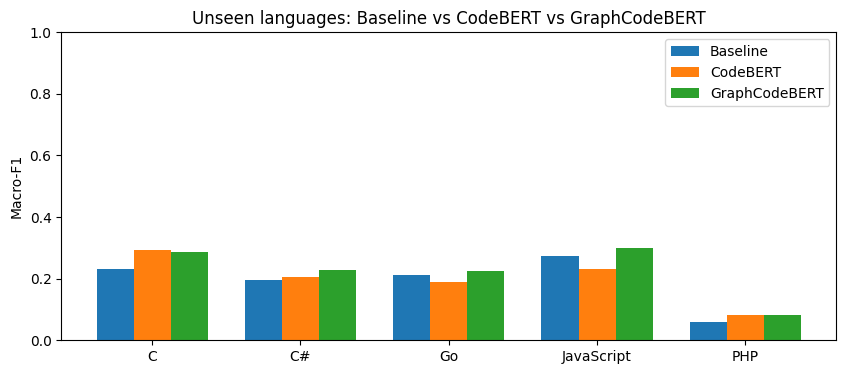

,language,n,macro_f1_baseline,macro_f1_codebert,macro_f1_gcb
0,C,51,0.230561,0.291667,0.287267
1,C#,121,0.194200,0.205765,0.228316
2,Go,60,0.210526,0.189189,0.223915
3,JavaScript,85,0.273504,0.230826,0.298349
4,PHP,48,0.058824,0.081739,0.081739


In [ ]:
import matplotlib.pyplot as plt

df_plot = (base_by_lang
           .merge(cb_by_lang, on=["language", "n"])
           .merge(gcb_unseen_by_lang, on=["language", "n"])
          ).sort_values("language")

x = np.arange(len(df_plot))
plt.figure(figsize=(10,4))
plt.bar(x - 0.25, df_plot["macro_f1_baseline"], 0.25, label="Baseline")
plt.bar(x,         df_plot["macro_f1_codebert"], 0.25, label="CodeBERT")
plt.bar(x + 0.25, df_plot["macro_f1_gcb"],       0.25, label="GraphCodeBERT")
plt.xticks(x, df_plot["language"])
plt.ylabel("Macro-F1")
plt.title("Unseen languages: Baseline vs CodeBERT vs GraphCodeBERT")
plt.ylim(0, 1)
plt.legend()
plt.show()

df_plot


#Blind tests results


In [ ]:
group = df_pred.groupby("len_bin")[["pred_baseline", "pred_codebert", "pred_gcb"]].mean()
group


/tmp/ipython-input-3928375954.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df_pred.groupby("len_bin")[["pred_baseline", "pred_codebert", "pred_gcb"]].mean()


,pred_baseline,pred_codebert,pred_gcb
len_bin,,,
"(1.999, 274.0]",0.748757,0.710563,0.730853
"(274.0, 382.0]",0.876105,0.847669,0.854200
"(382.0, 503.0]",0.911730,0.879622,0.878231
"(503.0, 651.0]",0.933534,0.899199,0.892492
"(651.0, 843.0]",0.944706,0.926141,0.908680
"(843.0, 1103.0]",0.957715,0.937876,0.912224
"(1103.0, 1472.0]",0.961696,0.939294,0.913391
"(1472.0, 2065.0]",0.970818,0.936538,0.916550
"(2065.0, 3231.0]",0.974300,0.924800,0.898900


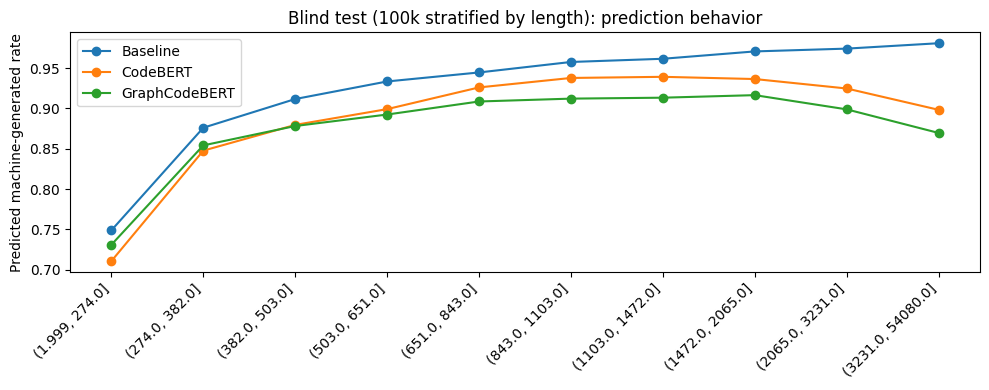

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(group.index.astype(str), group["pred_baseline"], marker="o", label="Baseline")
plt.plot(group.index.astype(str), group["pred_codebert"], marker="o", label="CodeBERT")
plt.plot(group.index.astype(str), group["pred_gcb"], marker="o", label="GraphCodeBERT")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Predicted machine-generated rate")
plt.title("Blind test (100k stratified by length): prediction behavior")
plt.legend()
plt.tight_layout()
plt.show()
